# Day 5: Distributions — Normal Distribution & Skewness

**90-Day Data Science Roadmap**

## Topics covered
- Normal distribution: bell curve, mean ≈ median ≈ mode
- The 68-95-99.7 empirical rule
- Skewness: right-skewed vs left-skewed
- Kurtosis: heavy tails / extreme outliers
- Visualizing distributions with histograms
- Fixing skew with log transform (and when it does NOT work)


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy import stats

## 1. Village Money (10 people, 1 extreme outlier)

9 friends with normal pocket money, plus 1 "billionaire" friend. This is our intuition-building example for skewness.

In [2]:
np.random.seed(1)

money = [50, 45, 60, 55, 40, 48, 52, 58, 47, 5000]

mean_money = np.mean(money)
median_money = np.median(money)

print("Mean:", mean_money)
print("Median:", median_money)

Mean: 545.5
Median: 51.0


Mean is pulled way above the median by the one outlier — a strong sign of right-skew before we even compute skewness officially.

In [3]:
skew_money = skew(money)
print("Skewness:", skew_money)

Skewness: 2.6665922302436647


In [4]:
kurt_money = kurtosis(money)
print("Kurtosis:", kurt_money)

Kurtosis: 5.110879540889869


Skew is strongly positive (right-skewed) and kurtosis is very high — this tiny dataset has one extremely heavy-tailed outlier.

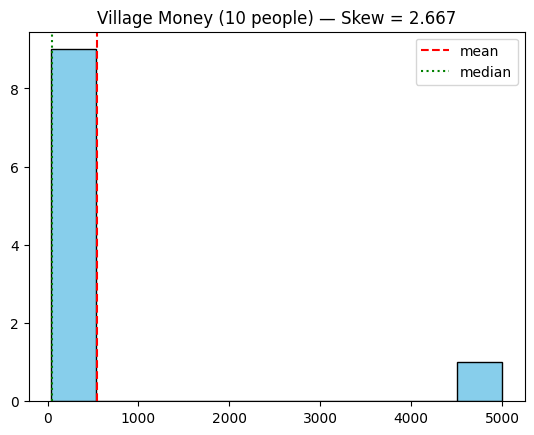

In [5]:
plt.hist(money, bins=10, color="skyblue", edgecolor="black")
plt.axvline(mean_money, color="red", linestyle="--", label="mean")
plt.axvline(median_money, color="green", linestyle=":", label="median")
plt.legend()
plt.title(f"Village Money (10 people) — Skew = {skew_money:.3f}")
plt.show()

In [6]:
# Try fixing the skew with log transform
log_money = np.log(money)
print("Skew before log:", skew(money))
print("Skew after log:", skew(log_money))

Skew before log: 2.6665922302436647
Skew after log: 2.6321570374415613


**Key finding:** the log transform barely helped here (`2.666` → `2.632`). With only 10 data points and one *insanely* extreme outlier (~100x bigger than everyone else), log transform can't fully fix the skew.

## 2. Village Money (100 people, realistic spread)

A bigger, more realistic right-skewed dataset — many people with gradually increasing income, not one extreme outlier.

In [7]:
np.random.seed(1)
village_money = np.random.lognormal(mean=4.0, sigma=0.6, size=100)
village_money = np.round(village_money, 1)

print(village_money[:10])

[144.7  37.8  39.8  28.7  91.8  13.7 155.5  34.6  66.1  47. ]


In [8]:
mean_v = np.mean(village_money)
median_v = np.median(village_money)
skew_v = skew(village_money)
kurt_v = kurtosis(village_money)

print("Mean:", mean_v)
print("Median:", median_v)
print("Skew:", skew_v)
print("Kurtosis:", kurt_v)

Mean: 65.17200000000001
Median: 56.75
Skew: 1.4525021063777404
Kurtosis: 2.3157490417198776


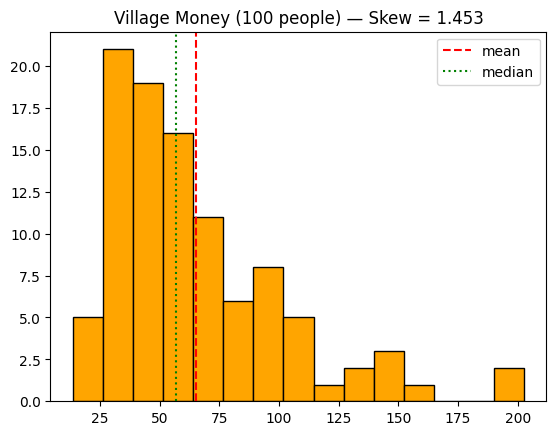

In [9]:
plt.hist(village_money, bins=15, color="orange", edgecolor="black")
plt.axvline(mean_v, color="red", linestyle="--", label="mean")
plt.axvline(median_v, color="green", linestyle=":", label="median")
plt.legend()
plt.title(f"Village Money (100 people) — Skew = {skew_v:.3f}")
plt.show()

In [10]:
log_village = np.log(village_money)
print("Skew before log:", skew(village_money))
print("Skew after log:", skew(log_village))

Skew before log: 1.4525021063777404
Skew after log: -0.004971113931140498


**Key finding:** log transform worked great here (`1.45` → `-0.005`, basically 0). With a larger sample and a gradual tail (not one freak outlier), log transform fixes right-skew properly.

## 3. Exam Scores (100 students, left-skewed)

Most students score high, a few score very low — this is left-skewed, the opposite direction from the village money examples.

In [11]:
np.random.seed(1)
scores = 100 - np.random.gamma(shape=2.0, scale=5.0, size=100)

mean_s = np.mean(scores)
median_s = np.median(scores)
skew_s = skew(scores)
kurt_s = kurtosis(scores)

print("Mean:", mean_s)
print("Median:", median_s)
print("Skew:", skew_s)
print("Kurtosis:", kurt_s)

Mean: 90.00559560403438
Median: 91.34841510008545
Skew: -1.3804365503759675
Kurtosis: 2.414117981626169


Mean < median and skew is negative — confirms left-skew, matching our prediction.

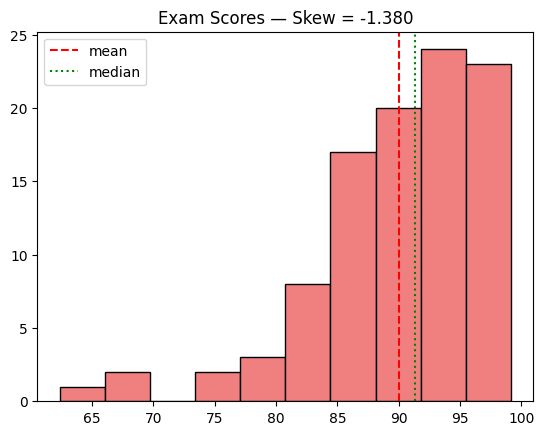

In [12]:
plt.hist(scores, bins=10, color="lightcoral", edgecolor="black")
plt.axvline(mean_s, color="red", linestyle="--", label="mean")
plt.axvline(median_s, color="green", linestyle=":", label="median")
plt.legend()
plt.title(f"Exam Scores — Skew = {skew_s:.3f}")
plt.show()

In [13]:
log_scores = np.log(scores)
print("Skew before log:", skew(scores))
print("Skew after log:", skew(log_scores))

Skew before log: -1.3804365503759675
Skew after log: -1.7278059007770026


**Key finding:** log transform made the skew WORSE here (`-1.38` → `-1.73`, further from 0). This is the most important lesson of the day:

> `np.log()` only fixes **right-skew**. It compresses big values a lot and small values barely at all — so applied to left-skewed data, it does not help and can make the skew more extreme.

To fix left-skewed data, a common approach is to flip it first (e.g. `max_value - data`, turning it into right-skew) and then apply log, or use a different transform entirely.

## 4. Comparing Kurtosis Across All Three Datasets

In [14]:
print("Kurtosis (village 10, extreme outlier):", kurtosis(money))
print("Kurtosis (village 100, realistic):", kurtosis(village_money))
print("Kurtosis (exam scores, left-skewed):", kurtosis(scores))

Kurtosis (village 10, extreme outlier): 5.110879540889869
Kurtosis (village 100, realistic): 2.3157490417198776
Kurtosis (exam scores, left-skewed): 2.414117981626169


The 10-person village has by far the highest kurtosis — one extreme outlier in a tiny dataset creates the heaviest tail of all three. Kurtosis and skew measure different things: skew is about *direction*, kurtosis is about *how extreme the outliers are*, regardless of direction.

## 5. Mode

Mode = the most frequently occurring value. It works best on data with repeated values (like grades or ratings), not continuous random data where nothing repeats.

In [15]:
grades = [85, 90, 85, 78, 90, 90, 88, 85, 92, 90]

mode_result = stats.mode(grades, keepdims=True)
print("Mode:", mode_result.mode[0], "| Count:", mode_result.count[0])

Mode: 90 | Count: 4


90 appears most often (4 times), so that's the mode. In a perfectly normal distribution, mean ≈ median ≈ mode — all three measures of 'typical value' agree.

## 6. The 68-95-99.7 Empirical Rule

For normally distributed data: ~68% of values fall within 1 standard deviation of the mean, ~95% within 2, and ~99.7% within 3. Let's verify this on 10,000 simulated normal data points.

In [16]:
np.random.seed(0)
heights = np.random.normal(loc=170, scale=10, size=10000)

mean = np.mean(heights)
std = np.std(heights)

within_1std = np.mean((heights > mean - std) & (heights < mean + std)) * 100
within_2std = np.mean((heights > mean - 2*std) & (heights < mean + 2*std)) * 100
within_3std = np.mean((heights > mean - 3*std) & (heights < mean + 3*std)) * 100

print(f"Within 1 std: {within_1std:.1f}% (expect ~68%)")
print(f"Within 2 std: {within_2std:.1f}% (expect ~95%)")
print(f"Within 3 std: {within_3std:.1f}% (expect ~99.7%)")

Within 1 std: 68.4% (expect ~68%)
Within 2 std: 95.5% (expect ~95%)
Within 3 std: 99.8% (expect ~99.7%)


Real simulated data lines up almost exactly with the textbook rule (68.4% / 95.5% / 99.8%) — confirming the empirical rule holds for normally distributed data.

## Summary — Key Takeaways

1. **Distribution shape** is read by comparing mean, median, and mode — when all three are close, data is roughly normal.
2. **Skew direction**: mean > median → right-skewed; mean < median → left-skewed.
3. **Skew size**: near 0 = balanced; beyond ±1 = strongly skewed.
4. **Kurtosis** measures extreme outliers/heavy tails — independent of skew direction.
5. **Log transform fixes right-skew specifically** — it does not work on left-skew, and can make it worse.
6. **Sample size and outlier extremity matter**: a tiny dataset with one insane outlier resists correction far more than a larger dataset with a gradual tail.
7. The **68-95-99.7 rule** holds reliably for normally distributed data, verified here on 10,000 simulated points.
